In [26]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/mlp-term-2-2025-kaggle-assignment-2/sample_submission.csv
/kaggle/input/mlp-term-2-2025-kaggle-assignment-2/train.csv
/kaggle/input/mlp-term-2-2025-kaggle-assignment-2/test.csv
260:	learn: 0.3137439	total: 10.3s	remaining: 1.53s
261:	learn: 0.3136929	total: 10.3s	remaining: 1.49s
262:	learn: 0.3136173	total: 10.3s	remaining: 1.45s
263:	learn: 0.3135716	total: 10.4s	remaining: 1.41s
264:	learn: 0.3134981	total: 10.4s	remaining: 1.37s
265:	learn: 0.3134228	total: 10.5s	remaining: 1.34s
266:	learn: 0.3133626	total: 10.5s	remaining: 1.3s
267:	learn: 0.3133068	total: 10.5s	remaining: 1.26s
268:	learn: 0.3132488	total: 10.6s	remaining: 1.22s
269:	learn: 0.3132104	total: 10.6s	remaining: 1.18s
270:	learn: 0.3131554	total: 10.7s	remaining: 1.14s
271:	learn: 0.3131119	total: 10.7s	remaining: 1.1s
272:	learn: 0.3130590	total: 10.7s	remaining: 1.06s
273:	learn: 0.3130216	total: 10.7s	remaining: 1.02s
274:	learn: 0.3129859	total: 10.8s	remaining: 980ms
275:	learn: 0.3129216	total: 10

## Objective:
To develop a machine learning model that predicts whether a customer will exit (churn) or stay with a financial institution.

Business Motivation:
Customer retention is critical in the banking sector. Predicting churn enables proactive engagement, improving customer satisfaction and reducing revenue loss.

Data Overview:

Dataset Size: 90,000 training samples, 30,000 test samples

Features: Demographic, account information, transaction patterns

Target Variable: Exited (1 = exited, 0 = stayed)

Class Imbalance: Dataset is imbalanced; majority of customers stayed.

Preprocessing Steps:

Handled missing/null values

Applied encoding to categorical variables

Scaled numerical features

Performed stratified train-test split to preserve class distribution

Modeling Approach:

Tested multiple classification algorithms: Logistic Regression, Random Forest, XGBoost, etc.

Applied resampling techniques (e.g., SMOTE) and class-weight tuning to handle imbalance

Used grid/randomized search for hyperparameter optimization

Performance Metrics Used:

Accuracy, Classification Report (Precision, Recall, F1-Score, AUC-ROC)

Focused on Recall and AUC due to imbalance in class distribution

Best Performing Model:

[Insert model name here, e.g., XGBoost] with [insert AUC or F1-score]

Achieved significant improvement over baseline (e.g., from 0.40 to [new score])

Business Insight:

Identified key churn indicators: [e.g., credit score, tenure, product usage]

Provided recommendations for targeted customer retention strategies

Tools & Technologies Used:
Python, Scikit-learn, Pandas, NumPy, Matplotlib, and Seaborn.

In [27]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

In [28]:
train_df=pd.read_csv('/kaggle/input/mlp-term-2-2025-kaggle-assignment-2/train.csv')
test_df=pd.read_csv('/kaggle/input/mlp-term-2-2025-kaggle-assignment-2/test.csv')
print(train_df.shape)
print(test_df.shape)

(90000, 14)
(30000, 13)


In [22]:
train_df.head()

,id,customer_id,last_name,credit_score,country,gender,age,tenure,acc_balance,prod_count,has_card,is_active,estimated_salary,exit_status
0,0,15788291,Iredale,559.0,France,Male,28.0,1,149989.39,1.0,1.0,1.0,67622.46,0
1,1,15642816,Hs?,694.0,France,Female,37.0,7,114510.35,2.0,0.0,0.0,182797.86,0
2,2,15632272,T'ien,585.0,NaN,Female,45.0,8,NaN,2.0,1.0,1.0,170338.35,0
3,3,15685826,Hightower,589.0,Spain,Male,25.0,0,166082.18,1.0,1.0,1.0,166476.46,0
4,4,15658032,Hopkins,701.0,France,Male,39.0,2,0.00,2.0,1.0,0.0,82526.92,0


In [23]:
test_df.head()

,id,customer_id,last_name,credit_score,country,gender,age,tenure,acc_balance,prod_count,has_card,is_active,estimated_salary
0,0,15765283,T'ien,645.0,France,Male,30.0,10,0.00,2.0,0.0,0.0,85901.09
1,1,15660157,Macleod,641.0,France,Male,37.0,10,146573.68,3.0,1.0,0.0,168023.72
2,2,15621267,Ejimofor,637.0,France,Female,32.0,6,0.00,1.0,0.0,0.0,148769.08
3,3,15651280,Nnaife,714.0,France,Male,37.0,7,0.00,2.0,1.0,0.0,172576.22
4,4,15764294,Ifeatu,716.0,Germany,Male,31.0,4,98899.91,1.0,1.0,1.0,47832.82


# RUBRICS 1 - Identify data types of different columns


In [29]:
numerical_cols=train_df.select_dtypes(include='number').columns.tolist()
print("NUM_COLS:",numerical_cols)
categorical_cols=train_df.select_dtypes(include='object').columns.tolist()
print("CATE_COLS:",categorical_cols)

NUM_COLS: ['id', 'customer_id', 'credit_score', 'age', 'tenure', 'acc_balance', 'prod_count', 'has_card', 'is_active', 'estimated_salary', 'exit_status']
CATE_COLS: ['last_name', 'country', 'gender']


In [25]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90000 entries, 0 to 89999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                90000 non-null  int64  
 1   customer_id       90000 non-null  int64  
 2   last_name         90000 non-null  object 
 3   credit_score      80444 non-null  float64
 4   country           83979 non-null  object 
 5   gender            90000 non-null  object 
 6   age               90000 non-null  float64
 7   tenure            90000 non-null  int64  
 8   acc_balance       82743 non-null  float64
 9   prod_count        85137 non-null  float64
 10  has_card          90000 non-null  float64
 11  is_active         90000 non-null  float64
 12  estimated_salary  90000 non-null  float64
 13  exit_status       90000 non-null  int64  
dtypes: float64(7), int64(4), object(3)
memory usage: 9.6+ MB


In [8]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                30000 non-null  int64  
 1   customer_id       30000 non-null  int64  
 2   last_name         30000 non-null  object 
 3   credit_score      26815 non-null  float64
 4   country           25394 non-null  object 
 5   gender            30000 non-null  object 
 6   age               30000 non-null  float64
 7   tenure            30000 non-null  int64  
 8   acc_balance       24749 non-null  float64
 9   prod_count        28283 non-null  float64
 10  has_card          30000 non-null  float64
 11  is_active         30000 non-null  float64
 12  estimated_salary  30000 non-null  float64
dtypes: float64(7), int64(3), object(3)
memory usage: 3.0+ MB


# RUBRICS 2 - Present descriptive statistics of numerical columns

In [78]:
train_df.describe()

,id,customer_id,credit_score,age,tenure,acc_balance,prod_count,has_card,is_active,estimated_salary,exit_status
count,90000.000000,9.000000e+04,80444.000000,90000.000000,90000.000000,82743.000000,85137.000000,90000.000000,90000.000000,90000.000000,90000.000000
mean,44999.500000,1.569209e+07,656.497054,38.119533,5.017022,55456.732147,1.552932,0.754289,0.497178,112394.659679,0.211600
std,25980.906451,7.129796e+04,80.016856,8.855203,2.804813,62788.474236,0.548011,0.430510,0.499995,50360.440702,0.408445
min,0.000000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.000000,0.000000,11.580000,0.000000
25%,22499.750000,1.563361e+07,597.000000,32.000000,3.000000,0.000000,1.000000,1.000000,0.000000,74430.360000,0.000000
50%,44999.500000,1.569016e+07,659.000000,37.000000,5.000000,0.000000,2.000000,1.000000,0.000000,117505.070000,0.000000
75%,67499.250000,1.575674e+07,710.000000,42.000000,7.000000,119825.750000,2.000000,1.000000,1.000000,154874.787500,0.000000
max,89999.000000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.000000,1.000000,199992.480000,1.000000


In [10]:
test_df.describe()

,id,customer_id,credit_score,age,tenure,acc_balance,prod_count,has_card,is_active,estimated_salary
count,30000.000000,3.000000e+04,26815.000000,30000.000000,30000.000000,24749.000000,28283.000000,30000.000000,30000.000000,30000.000000
mean,14999.500000,1.569190e+07,656.406041,38.118100,5.024167,55444.225343,1.553972,0.757833,0.495200,112664.246065
std,8660.398374,7.192854e+04,80.310093,8.873345,2.809931,62736.404013,0.545386,0.428402,0.499985,50064.348532
min,0.000000,1.556580e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.000000,0.000000,11.580000
25%,7499.750000,1.563220e+07,597.000000,32.000000,3.000000,0.000000,1.000000,1.000000,0.000000,74837.967500
50%,14999.500000,1.569021e+07,659.000000,37.000000,5.000000,0.000000,2.000000,1.000000,0.000000,118216.000000
75%,22499.250000,1.575758e+07,710.000000,42.000000,7.000000,119688.810000,2.000000,1.000000,1.000000,154920.805000
max,29999.000000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.000000,1.000000,199992.480000


# Class Imbalance Analysis – exit_status Column
•	Observed Class Distribution:
	Stayed (0): 70,956 customers (≈ 78.8%)
	Exited (1): 19,044 customers (≈ 21.2%)
•	Nature of Imbalance:
	The dataset is imbalanced, with the majority class (Stayed) significantly outnumbering the minority class (Exited).
	This imbalance can bias most machine learning models toward predicting the majority class, leading to misleadingly high accuracy but poor minority class performance.
•	Why This Is a Problem:
	A model may predict most customers as "Stayed" to achieve high accuracy but fail to identify actual churners.
	Important business use case (churn detection) focuses on minority class (Exited = 1), which is underrepresented.
•	Impact on Model Training:
	Standard classification algorithms may underperform on the minority class.
	Evaluation metrics like accuracy become unreliable in imbalanced settings.
	Metrics like Recall, Precision, F1-Score, and AUC-ROC are more appropriate.


In [30]:
train_df['exit_status']
train_df['exit_status'].value_counts()

exit_status
0    70956
1    19044
Name: count, dtype: int64

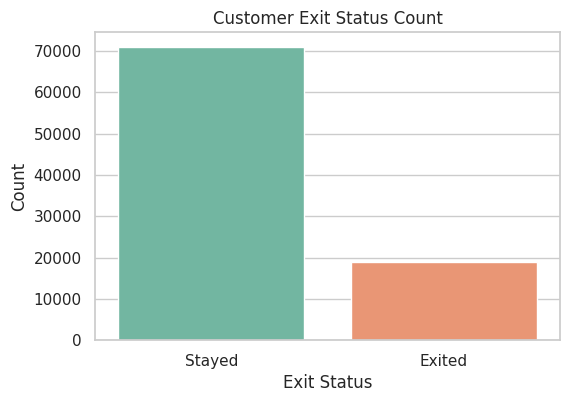

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set style
sns.set(style="whitegrid")

# Plot countplot
plt.figure(figsize=(6, 4))
sns.countplot(x='exit_status', data=train_df, palette='Set2')

# Add labels and title
plt.xticks([0, 1], ['Stayed', 'Exited'])
plt.title('Customer Exit Status Count')
plt.xlabel('Exit Status')
plt.ylabel('Count')

# Show plot
plt.show()


# RUBRICS 4 - Identify and handle duplicates

In [31]:
# Check for duplicates
print("Number of duplicate rows in train_data:", train_df.duplicated().sum())
print("Number of duplicate rows in test_data:", test_df.duplicated().sum())

# Remove duplicates
train_data = train_df.drop_duplicates().copy()
test_data = test_df.drop_duplicates().copy()

# Optionally, reset index (to keep it clean and aligned)
train_data.reset_index(drop=True, inplace=True)
test_data.reset_index(drop=True, inplace=True)

# Display new shape
print("Shape of train_data after removing duplicates:", train_data.shape)
print("Shape of test_data after removing duplicates:", test_data.shape)

Number of duplicate rows in train_data: 0
Number of duplicate rows in test_data: 0
Shape of train_data after removing duplicates: (90000, 14)
Shape of test_data after removing duplicates: (30000, 13)


# RUBRICS 5 - Identify and handle outliers

In [32]:
num_cols = ['credit_score', 'age', 'tenure', 'acc_balance', 'prod_count', 'has_card', 'is_active', 'estimated_salary']

def remove_outliers_iqr(df, cols):
    outlier_index = set()
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        # Add outlier indices
        outliers = df[(df[col] < lower) | (df[col] > upper)].index
        outlier_index.update(outliers)
    
    print(f"Removing {len(outlier_index)} rows containing outliers")
    # Drop outliers
    return df.drop(index=outlier_index).reset_index(drop=True)

# Apply to both datasets and overwrite
train_df1 = remove_outliers_iqr(train_data, num_cols)
#test_df1 = remove_outliers_iqr(test_data, num_cols)

print()
print("Shape of train_df after removing outliers:", train_df1.shape)
#print("Shape of test_df after removing outliers:", test_df1.shape)

Removing 24901 rows containing outliers

Shape of train_df after removing outliers: (65099, 14)


In [30]:
train_df1.shape

(65099, 14)

In [31]:
test_data.shape

(30000, 13)

# RUBRICS 3 - Identify and handle the missing values

In [32]:
train_df1.isna().sum()

id                     0
customer_id            0
last_name              0
credit_score        6911
country             4389
gender                 0
age                    0
tenure                 0
acc_balance         5235
prod_count          3551
has_card               0
is_active              0
estimated_salary       0
exit_status            0
dtype: int64

<Axes: >

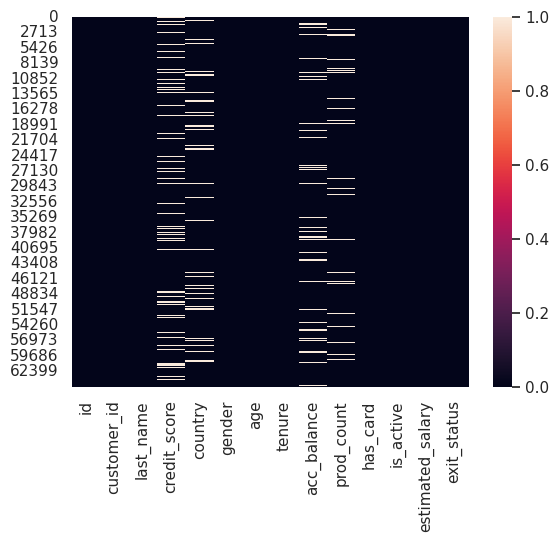

In [33]:
import seaborn as sns
sns.heatmap(train_df1.isna())

In [34]:
test_data.isna().sum()

id                     0
customer_id            0
last_name              0
credit_score        3185
country             4606
gender                 0
age                    0
tenure                 0
acc_balance         5251
prod_count          1717
has_card               0
is_active              0
estimated_salary       0
dtype: int64

<Axes: >

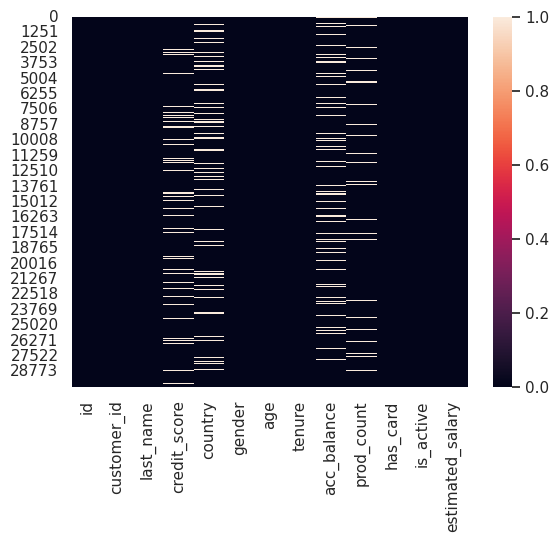

In [35]:
sns.heatmap(test_data.isna())

# features to remove (columns to drop) id: customer_id: Just an identifier, no predictive power. last_name: Not relevant for prediction; could introduce noise or bias

In [33]:
y=train_df1['exit_status']
y.shape

(65099,)

In [34]:
train_df1.drop(['id', 'customer_id', 'last_name','exit_status'],axis=1,inplace=True)
test_df.drop(['id', 'customer_id', 'last_name'],axis=1,inplace=True)

In [38]:
train_df1.shape

(65099, 10)

In [39]:
test_df.shape

(30000, 10)

In [40]:
train_df1.head()

,credit_score,country,gender,age,tenure,acc_balance,prod_count,has_card,is_active,estimated_salary
0,559.0,France,Male,28.0,1,149989.39,1.0,1.0,1.0,67622.46
1,585.0,NaN,Female,45.0,8,NaN,2.0,1.0,1.0,170338.35
2,589.0,Spain,Male,25.0,0,166082.18,1.0,1.0,1.0,166476.46
3,701.0,France,Male,39.0,2,0.00,2.0,1.0,0.0,82526.92
4,587.0,France,Male,36.0,1,171770.55,1.0,1.0,1.0,70954.66


In [41]:
test_data.head()

,id,customer_id,last_name,credit_score,country,gender,age,tenure,acc_balance,prod_count,has_card,is_active,estimated_salary
0,0,15765283,T'ien,645.0,France,Male,30.0,10,0.00,2.0,0.0,0.0,85901.09
1,1,15660157,Macleod,641.0,France,Male,37.0,10,146573.68,3.0,1.0,0.0,168023.72
2,2,15621267,Ejimofor,637.0,France,Female,32.0,6,0.00,1.0,0.0,0.0,148769.08
3,3,15651280,Nnaife,714.0,France,Male,37.0,7,0.00,2.0,1.0,0.0,172576.22
4,4,15764294,Ifeatu,716.0,Germany,Male,31.0,4,98899.91,1.0,1.0,1.0,47832.82


In [42]:
train_df1[['credit_score', 'age', 'tenure', 'acc_balance', 'prod_count', 'has_card', 'is_active', 'estimated_salary']].skew()

credit_score       -0.041018
age                 0.365907
tenure              0.004384
acc_balance         0.408889
prod_count          0.126855
has_card            0.000000
is_active           0.068953
estimated_salary   -0.311947
dtype: float64

In [ ]:
#from imblearn.over_sampling import SMOTE

#sm = SMOTE(random_state=42)
#train_df2, y_df2 = sm.fit_resample(train_df1, y)


In [35]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(train_df1,y,stratify=y,test_size=0.10,random_state=42)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(58589, 10)
(6510, 10)
(58589,)
(6510,)


In [86]:
X_train.head()

,credit_score,country,gender,age,tenure,acc_balance,prod_count,has_card,is_active,estimated_salary
35487,748.0,France,Male,50.0,5,124497.95,NaN,1.0,0.0,58854.86
14593,727.0,France,Female,39.0,3,126773.43,1.0,1.0,1.0,183963.34
23548,645.0,France,Female,33.0,6,0.00,2.0,1.0,0.0,125870.50
15078,455.0,Spain,Female,57.0,4,0.00,1.0,1.0,1.0,176712.59
26715,593.0,NaN,Female,49.0,7,131778.08,1.0,1.0,0.0,172450.04


# RUBRICS 7 - Scale Numerical features and Encode Categorical features

In [36]:
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns

# Numerical features (based on your list)
num_cols = ['credit_score', 'age', 'tenure', 'acc_balance', 'prod_count',
            'has_card', 'is_active', 'estimated_salary']

# Categorical features
cat_cols = ['country', 'gender']

# Step 1: Check skewness
skew_values = train_df[num_cols].skew()
print("Skewness values:\n", skew_values)

# Step 2: Choose imputation strategy
mean_impute_cols = skew_values[(skew_values.abs() <= 0.5)].index.tolist()
median_impute_cols = [col for col in num_cols if col not in mean_impute_cols]

print("Mean strategy:", mean_impute_cols)
print("Median strategy:", median_impute_cols)

# Step 3: Create transformers
mean_imputer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

median_imputer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore',sparse_output=False))
])

# Step 4: ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('mean_num', mean_imputer, mean_impute_cols),
    ('median_num', median_imputer, median_impute_cols),
    ('cat', cat_transformer, cat_cols)
],remainder='passthrough')
X_train_final=preprocessor.fit_transform(X_train)
X_test_final=preprocessor.transform(X_test)
test_final=preprocessor.transform(test_df)
# Step 5: Final pipeline (example using RandomForestClassifier)
#train_data = Pipeline(steps=[
   # ('preprocessing', preprocessor),
    #('classifier', RandomForestClassifier(random_state=42)])

# Usage:
# X = train_df.drop(columns=['exit_status', 'id', 'customer_id', 'last_name'])
# y = train_df['exit_status']
# clf_pipeline.fit(X, y)

Skewness values:
 credit_score       -0.065250
age                 0.945116
tenure              0.008847
acc_balance         0.382636
prod_count          0.386475
has_card           -1.181363
is_active           0.011289
estimated_salary   -0.305339
dtype: float64
Mean strategy: ['credit_score', 'tenure', 'acc_balance', 'prod_count', 'is_active', 'estimated_salary']
Median strategy: ['age', 'has_card']


In [37]:
import pandas as pd

# Helper function to get feature names from the ColumnTransformer
def get_feature_names(column_transformer):
    output_features = []

    for name, trans, cols in column_transformer.transformers_:
        if name == 'remainder':
            continue

        if hasattr(trans, 'named_steps'):
            if 'encoder' in trans.named_steps:
                encoder = trans.named_steps['encoder']
                encoded_names = encoder.get_feature_names_out(cols)
                output_features.extend(encoded_names)
            else:
                output_features.extend(cols)
        else:
            output_features.extend(cols)

    return output_features

# Get final column names after transformation
final_column_names = get_feature_names(preprocessor)

# Convert transformed NumPy arrays to DataFrames
X_train_df = pd.DataFrame(X_train_final, columns=final_column_names, index=X_train.index)
X_test_df = pd.DataFrame(X_test_final, columns=final_column_names, index=X_test.index)
test_final1=pd.DataFrame(test_final, columns=final_column_names)
# If `test_prediction` is the transformed test dataset (before prediction), convert it:
# Ensure it has the same shape as X_train_final/X_test_final
#test_data = pd.DataFrame(test_prediction, columns=final_column_names)

# If needed, set the appropriate index (usually test set's index if available)
# Only if `test_df1` was used for predictions
# test_data.index = test_df1.index  # Uncomment and use if applicable


In [46]:
print(X_test_df.shape)
print(test_final1.shape)

(9765, 13)
(30000, 13)


In [63]:
X_train_df.head()

,credit_score,tenure,acc_balance,prod_count,is_active,estimated_salary,age,has_card,country_France,country_Germany,country_Spain,gender_Female,gender_Male
35487,748.0,5.0,124497.95,1.552185,0.0,58854.86,50.0,1.0,1.0,0.0,0.0,0.0,1.0
14593,727.0,3.0,126773.43,1.000000,1.0,183963.34,39.0,1.0,1.0,0.0,0.0,1.0,0.0
23548,645.0,6.0,0.00,2.000000,0.0,125870.50,33.0,1.0,1.0,0.0,0.0,1.0,0.0
15078,455.0,4.0,0.00,1.000000,1.0,176712.59,57.0,1.0,0.0,0.0,1.0,1.0,0.0
26715,593.0,7.0,131778.08,1.000000,0.0,172450.04,49.0,1.0,1.0,0.0,0.0,1.0,0.0


In [34]:
X_train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 52079 entries, 47308 to 56422
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   credit_score      52079 non-null  float64
 1   tenure            52079 non-null  float64
 2   acc_balance       52079 non-null  float64
 3   prod_count        52079 non-null  float64
 4   is_active         52079 non-null  float64
 5   estimated_salary  52079 non-null  float64
 6   age               52079 non-null  float64
 7   has_card          52079 non-null  float64
 8   country_France    52079 non-null  float64
 9   country_Germany   52079 non-null  float64
 10  country_Spain     52079 non-null  float64
 11  gender_Female     52079 non-null  float64
 12  gender_Male       52079 non-null  float64
dtypes: float64(13)
memory usage: 5.6 MB


In [35]:
X_test_df.head()

,credit_score,tenure,acc_balance,prod_count,is_active,estimated_salary,age,has_card,country_France,country_Germany,country_Spain,gender_Female,gender_Male
10180,0.247108,1.060197,-0.907860,0.869306,-0.965959,0.881947,-0.010809,0.0,1.0,0.0,0.0,0.0,1.0
4293,0.018402,-1.442380,1.240609,-1.072170,1.035241,-0.757121,0.941191,0.0,0.0,1.0,0.0,0.0,1.0
15978,0.233654,0.702686,-0.907860,0.869306,-0.965959,0.785817,0.125191,0.0,1.0,0.0,0.0,0.0,1.0
30411,0.000000,-0.012336,1.108719,0.869306,1.035241,-0.757167,-0.826808,0.0,0.0,1.0,0.0,0.0,1.0
55896,-1.945780,0.345175,0.852589,0.869306,1.035241,1.126517,1.621191,0.0,0.0,1.0,0.0,1.0,0.0


In [36]:
X_test_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13020 entries, 10180 to 53939
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   credit_score      13020 non-null  float64
 1   tenure            13020 non-null  float64
 2   acc_balance       13020 non-null  float64
 3   prod_count        13020 non-null  float64
 4   is_active         13020 non-null  float64
 5   estimated_salary  13020 non-null  float64
 6   age               13020 non-null  float64
 7   has_card          13020 non-null  float64
 8   country_France    13020 non-null  float64
 9   country_Germany   13020 non-null  float64
 10  country_Spain     13020 non-null  float64
 11  gender_Female     13020 non-null  float64
 12  gender_Male       13020 non-null  float64
dtypes: float64(13)
memory usage: 1.4 MB


# RUBRICS 6 - Present at least three visualizations and provide insights for the same

Axes(0.125,0.11;0.775x0.77)


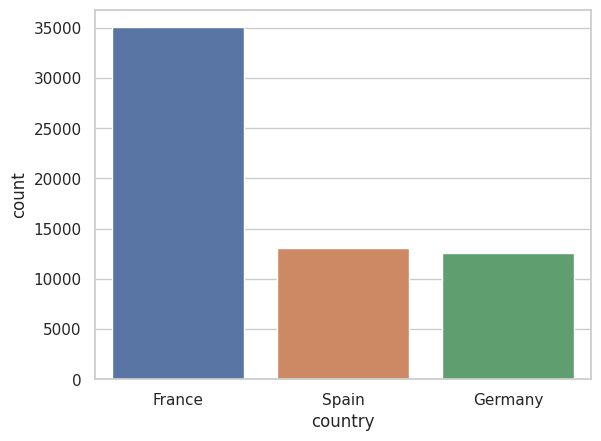

In [47]:
print(sns.countplot(x='country',data=train_df1))

Axes(0.125,0.11;0.775x0.77)


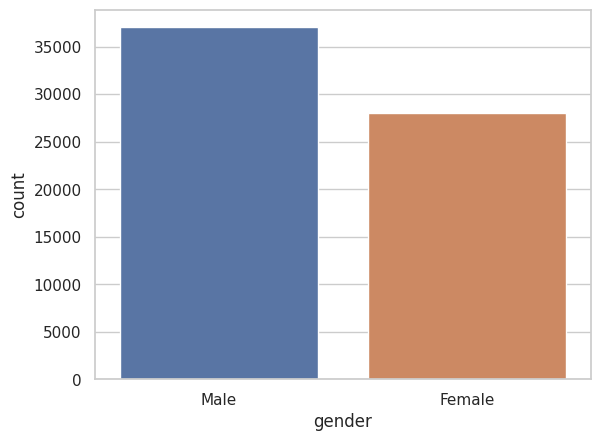

In [48]:
print(sns.countplot(x='gender',data=train_df1))

Axes(0.125,0.11;0.775x0.77)


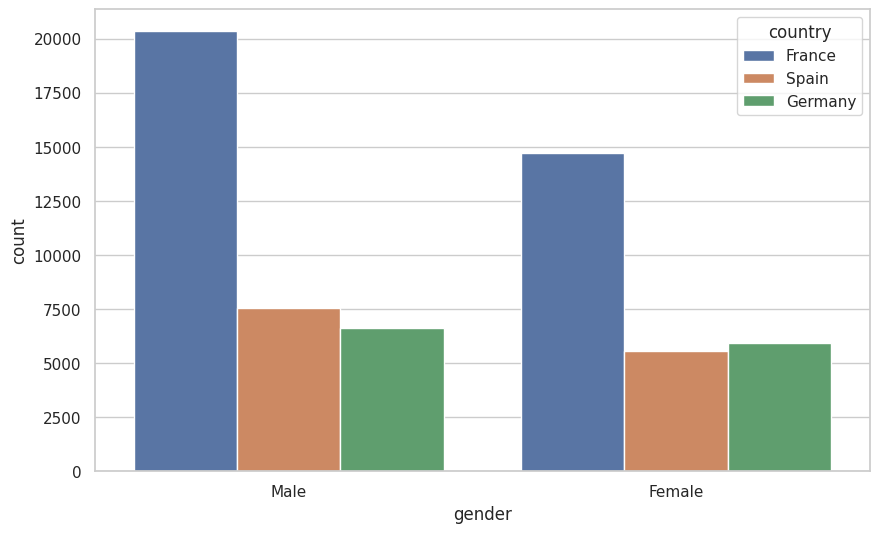

In [49]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
print(sns.countplot(x='gender',data=train_df1,hue='country'))

In [50]:
# Select only numeric columns
num_cols = X_train_df.select_dtypes(include='number').columns.tolist()

# Optionally exclude ID columns if present
num_cols = [col for col in num_cols if col not in ['id', 'customer_id']]
# Compute correlation matrix
corr_matrix = X_train_df[num_cols].corr()

# Display top 5 correlated pairs
print("\nCorrelation matrix:\n", corr_matrix.round(2))



Correlation matrix:
                   credit_score  tenure  acc_balance  prod_count  is_active  \
credit_score              1.00    0.00         0.00        0.01       0.01   
tenure                    0.00    1.00        -0.01        0.00      -0.00   
acc_balance               0.00   -0.01         1.00       -0.36      -0.02   
prod_count                0.01    0.00        -0.36        1.00       0.05   
is_active                 0.01   -0.00        -0.02        0.05       1.00   
estimated_salary         -0.01    0.00         0.01       -0.01      -0.01   
age                      -0.01   -0.01         0.07       -0.12      -0.06   
has_card                   NaN     NaN          NaN         NaN        NaN   
country_France           -0.01   -0.00        -0.30        0.06       0.02   
country_Germany           0.01   -0.00         0.50       -0.11      -0.04   
country_Spain             0.00    0.01        -0.12        0.03       0.01   
gender_Female             0.00   -0.01    

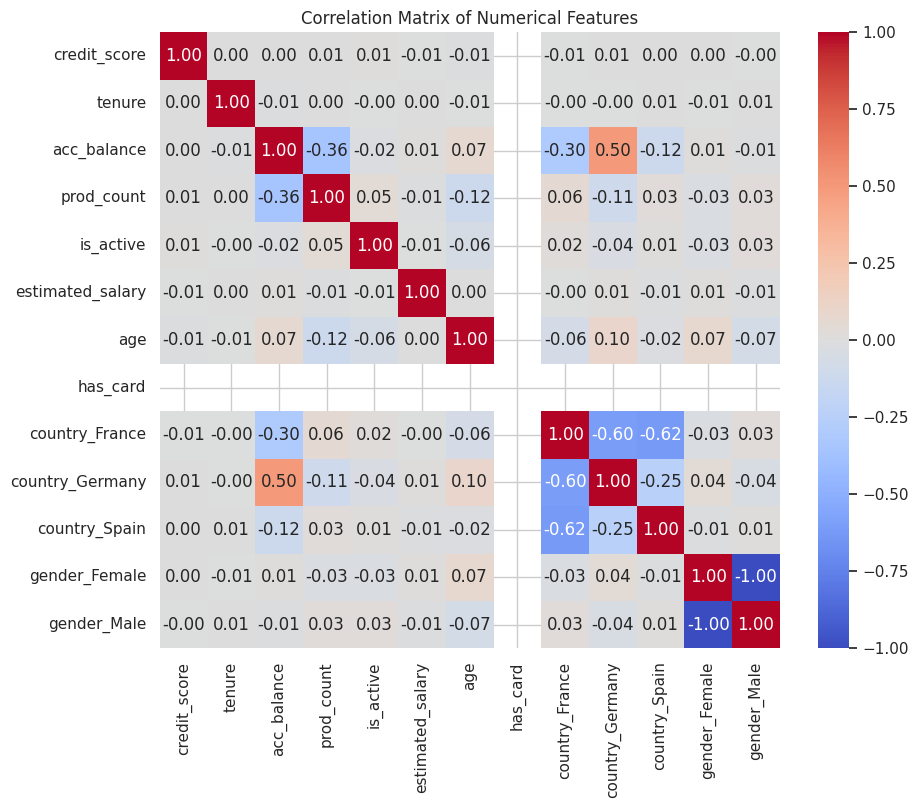

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title("Correlation Matrix of Numerical Features")
plt.show()

In [39]:
def get_correlation_pairs(corr_matrix, threshold_high=0.75, threshold_low=0.2):
    corr_pairs = corr_matrix.unstack().reset_index()
    corr_pairs.columns = ['Feature1', 'Feature2', 'Correlation']
    
    # Remove self-correlations and duplicate pairs
    corr_pairs = corr_pairs[corr_pairs['Feature1'] != corr_pairs['Feature2']]
    corr_pairs = corr_pairs.drop_duplicates(subset=['Correlation'])
    
    high_corr = corr_pairs[abs(corr_pairs['Correlation']) > threshold_high]
    low_corr = corr_pairs[abs(corr_pairs['Correlation']) < threshold_low]

    return high_corr.sort_values(by='Correlation', ascending=False), low_corr.sort_values(by='Correlation')

# Get correlation pairs
high_corr_pairs, low_corr_pairs = get_correlation_pairs(corr_matrix)

print("\n🔗 Highly correlated feature pairs (>|0.75|):")
print(high_corr_pairs)

print("\n🔍 Weakly correlated feature pairs (<|0.2|):")
print(low_corr_pairs)


🔗 Highly correlated feature pairs (>|0.75|):
          Feature1     Feature2  Correlation
155  gender_Female  gender_Male         -1.0

🔍 Weakly correlated feature pairs (<|0.2|):
             Feature1          Feature2  Correlation
45         prod_count               age    -0.123189
36        acc_balance     country_Spain    -0.117864
48         prod_count   country_Germany    -0.107853
90                age       gender_Male    -0.074386
86                age    country_France    -0.068284
58          is_active               age    -0.060223
129   country_Germany       gender_Male    -0.038999
61          is_active   country_Germany    -0.037516
63          is_active     gender_Female    -0.032112
115    country_France     gender_Female    -0.027061
50         prod_count     gender_Female    -0.022243
30        acc_balance         is_active    -0.021221
88                age     country_Spain    -0.018582
6        credit_score               age    -0.011363
44         prod_count  e

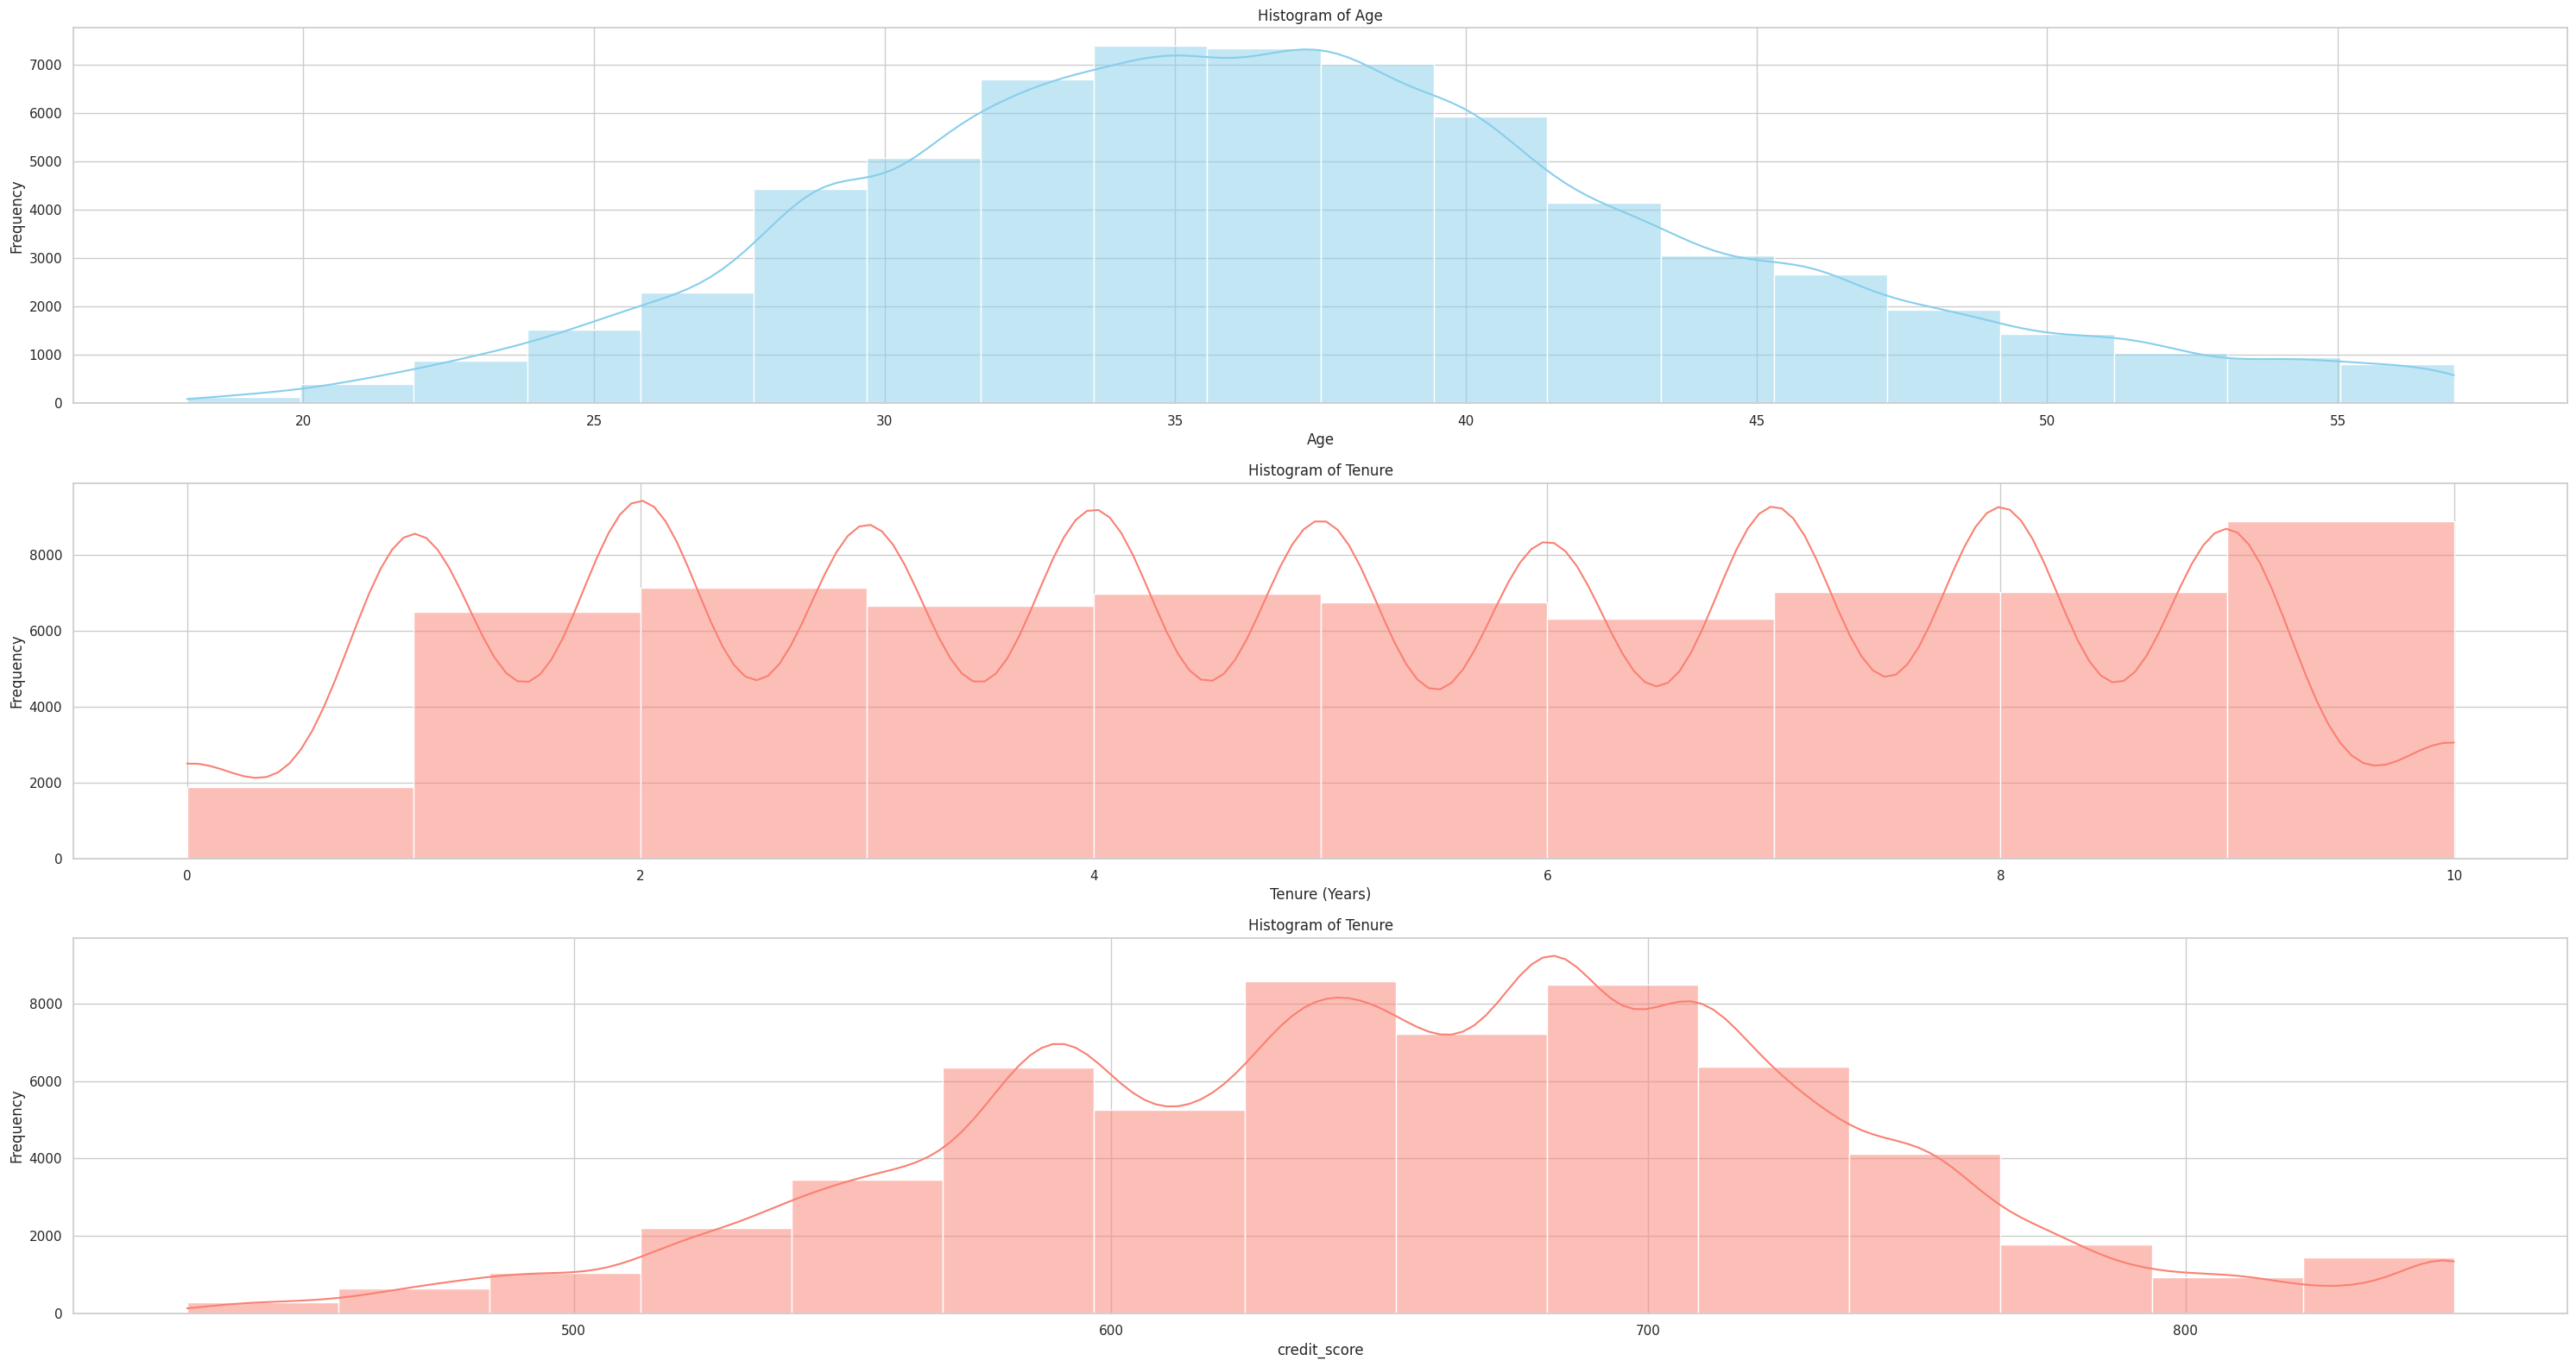

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set(style='whitegrid')

# Plotting histograms
plt.figure(figsize=(30, 16))

# Histogram for Age
plt.subplot(3, 1, 1)
sns.histplot(train_df1['age'], bins=20, kde=True, color='skyblue')
plt.title('Histogram of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')

# Histogram for Tenure
plt.subplot(3, 1, 2)
sns.histplot(train_df1['tenure'], bins=10, kde=True, color='salmon')
plt.title('Histogram of Tenure')
plt.xlabel('Tenure (Years)')
plt.ylabel('Frequency')

# Histogram for Credit Score
plt.subplot(3, 1, 3)
sns.histplot(train_df1['credit_score'], bins=15, kde=True, color='salmon')
plt.title('Histogram of Tenure')
plt.xlabel('credit_score')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


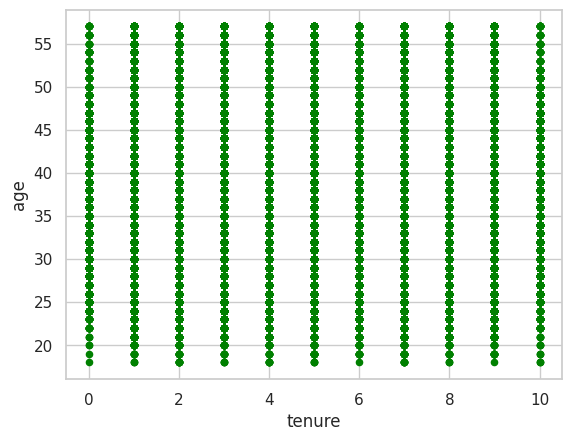

In [113]:
train_df1.plot.scatter(x='tenure',y='age',c='green')
plt.show()

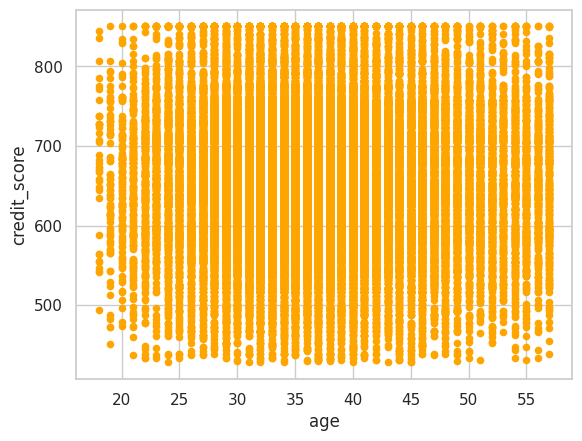

In [114]:
train_df1.plot.scatter(x='age',y='credit_score',c='orange')
plt.show()

# RUBRICS 8 - Model Building (at least 7)

In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from catboost import CatBoostClassifier

# Define models
models = {
    "Logistic Regression": LogisticRegression(class_weight='balanced', max_iter=200),
    "Decision Tree": DecisionTreeClassifier(class_weight='balanced', random_state=42),
    "Random Forest": RandomForestClassifier(class_weight='balanced', random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Support Vector Machine": SVC(),
    "CatBoostClassifier": CatBoostClassifier(
    iterations=300,
    learning_rate=0.05,
    depth=6,
    random_state=42,
    verbose=100,
    scale_pos_weight=3.73
)
}

# Train, predict and evaluate
for name, model in models.items():
    print("="*60)
    print(f"🔍 Model: {name}")
    
    # Fit model
    model.fit(X_train_df, y_train)
    
    # Predict
    y_pred = model.predict(X_test_df)
    
    # Accuracy
    acc = accuracy_score(y_test, y_pred)
    print(f"✅ Accuracy: {acc:.4f}")
    
    # Classification report
    print("📊 Classification Report:")
    print(classification_report(y_test, y_pred))

🔍 Model: Logistic Regression
✅ Accuracy: 0.7610
📊 Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.76      0.84      5221
           1       0.44      0.76      0.56      1289

    accuracy                           0.76      6510
   macro avg       0.68      0.76      0.70      6510
weighted avg       0.83      0.76      0.78      6510

🔍 Model: Decision Tree
✅ Accuracy: 0.8057
📊 Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.88      0.88      5221
           1       0.51      0.52      0.52      1289

    accuracy                           0.81      6510
   macro avg       0.70      0.70      0.70      6510
weighted avg       0.81      0.81      0.81      6510

🔍 Model: Random Forest
✅ Accuracy: 0.8651
📊 Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.95      0.92      5221
           1       0.73      0

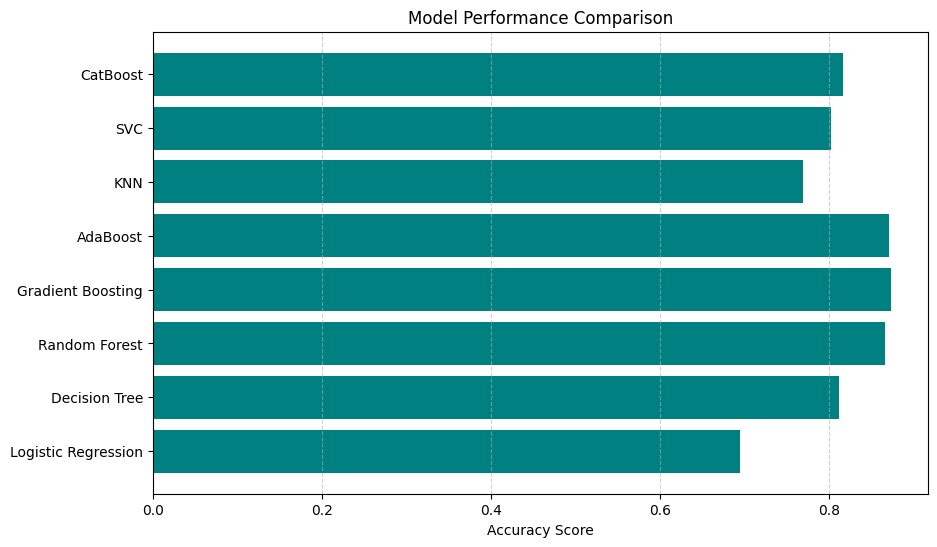

✅ Best Performing Model: Gradient Boosting with accuracy 0.8725


In [39]:
import matplotlib.pyplot as plt

# Example scores dictionary (replace these with your actual scores)
model_scores = {
    'Logistic Regression': 0.6943,
    'Decision Tree' : 0.8109,
    'Random Forest': 0.8651,
    'Gradient Boosting': 0.8725,
    'AdaBoost' : 0.8706,
    'KNN': 0.7683,
    'SVC': 0.8019,
    'CatBoost':0.8165
}

# Plotting
plt.figure(figsize=(10, 6))
plt.barh(list(model_scores.keys()), list(model_scores.values()), color='teal')
plt.xlabel('Accuracy Score')
plt.title('Model Performance Comparison')
plt.grid(True, axis='x', linestyle='--', alpha=0.6)
plt.show()

# Best model selection
best_model_name = max(model_scores, key=model_scores.get)
print(f"✅ Best Performing Model: {best_model_name} with accuracy {model_scores[best_model_name]:.4f}")

# RUBRICS 9 - Hyperparameter Tuning on any 3 of the models

In [40]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

# 1. Random Forest
from sklearn.ensemble import RandomForestClassifier
rf_params = {
    'n_estimators': [50, 100, 150],
    'max_depth': [5, 10, 20, None],
    'min_samples_split': [2, 5, 10],
    'bootstrap': [True, False]
}
rf_model = RandomForestClassifier(random_state=42)
rf_search = RandomizedSearchCV(rf_model, rf_params, n_iter=10, cv=3, scoring='accuracy', n_jobs=-1, random_state=42)

# 2. Gradient Boosting
from sklearn.ensemble import GradientBoostingClassifier
gb_params = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7]
}
gb_model = GradientBoostingClassifier(random_state=42)
gb_search = RandomizedSearchCV(gb_model, gb_params, n_iter=10, cv=3, scoring='accuracy', n_jobs=-1, random_state=42)

# 3. Logistic Regression
from sklearn.linear_model import LogisticRegression
lr_params = {
    'C': np.logspace(-3, 3, 10),
    'penalty': ['l2'],
    'solver': ['lbfgs', 'liblinear']
}
lr_model = LogisticRegression(max_iter=100)
lr_search = RandomizedSearchCV(lr_model, lr_params, n_iter=10, cv=3, scoring='accuracy', n_jobs=-1, random_state=42)

 #4. Support Vector Machine
#from sklearn.svm import SVC
#svc_params = {
 # 'C': [0.1, 1, 10],
  # 'kernel': ['linear', 'rbf'],
   #'gamma': ['scale', 'auto']}
#svc_model = SVC()
#svc_search = RandomizedSearchCV(svc_model, svc_params, n_iter=10, cv=3, scoring='accuracy', n_jobs=-1, random_state=42)

# 5. K-Nearest Neighbors
#from sklearn.neighbors import KNeighborsClassifier
#knn_params = {
 #   'n_neighbors': [3, 5, 7, 9],
  #  'weights': ['uniform', 'distance'],
   # 'metric': ['euclidean', 'manhattan']}
#knn_model = KNeighborsClassifier()
#knn_search = RandomizedSearchCV(knn_model, knn_params, n_iter=10, cv=3, scoring='accuracy', n_jobs=-1, random_state=42)

#6 CatBoostClassifier
from catboost import CatBoostClassifier
cbm_params = {
    'depth': [4, 6, 8, 10],
    'learning_rate': [0.01, 0.05, 0.1],
    'iterations': [100, 300, 500],
    'l2_leaf_reg': [1, 3, 5, 7],
    'border_count': [32, 64, 128]
}

#cbm_params={}
cbm_model=CatBoostClassifier()
cbm_search = RandomizedSearchCV(cbm_model, cbm_params, n_iter=10, cv=3, scoring='accuracy', n_jobs=-1, random_state=42)


# RUBRICS 10 - MODELS PERFORMANCE COMPARISONS

In [41]:
# List of tuned models
tuned_models = {
    'Random Forest': rf_search,
    'Gradient Boosting': gb_search,
    'Logistic Regression': lr_search,
   # 'SVC': svc_search,
    #'KNN': knn_search
    'CatBoostClassifier':cbm_search
}

# Fit, predict, and evaluate each
for name, model in tuned_models.items():
    print("="*60)
    print(f"🔍 Tuning Model: {name}")
    
    # Fit search
    model.fit(X_train_df, y_train)
    
    # Predict
    y_pred = model.best_estimator_.predict(X_test_df)
    
    # Evaluate
    print(f"✅ Best Params: {model.best_params_}")
    print(f"✅ Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print("📊 Classification Report:")
    print(classification_report(y_test, y_pred))

🔍 Tuning Model: Random Forest
✅ Best Params: {'n_estimators': 100, 'min_samples_split': 2, 'max_depth': 10, 'bootstrap': True}
✅ Accuracy: 0.8705
📊 Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.96      0.92      5221
           1       0.77      0.49      0.60      1289

    accuracy                           0.87      6510
   macro avg       0.83      0.73      0.76      6510
weighted avg       0.86      0.87      0.86      6510

🔍 Tuning Model: Gradient Boosting
✅ Best Params: {'n_estimators': 50, 'max_depth': 5, 'learning_rate': 0.1}
✅ Accuracy: 0.8728
📊 Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.95      0.92      5221
           1       0.74      0.55      0.63      1289

    accuracy                           0.87      6510
   macro avg       0.82      0.75      0.78      6510
weighted avg       0.86      0.87      0.87      6510

🔍 Tuning Model: Logisti

In [43]:
test_pred = model.best_estimator_.predict(test_final1)
test_pred=np.clip(test_pred, 0, None)

In [44]:
submission = pd.DataFrame({
    "id": range(test_data.shape[0]),
    "exit_status": test_pred
})
submission.to_csv("submission.csv", index=False)
submission

,id,exit_status
0,0,0
1,1,1
2,2,0
3,3,0
4,4,0
...,...,...
29995,29995,0
29996,29996,1
29997,29997,1
29998,29998,0


298:	learn: 0.2938516	total: 26.5s	remaining: 88.7ms
299:	learn: 0.2937600	total: 26.6s	remaining: 0us
0:	learn: 0.6662221	total: 20.5ms	remaining: 2.03s
1:	learn: 0.6417407	total: 36ms	remaining: 1.76s
2:	learn: 0.6187927	total: 44.8ms	remaining: 1.45s
3:	learn: 0.5978463	total: 69.6ms	remaining: 1.67s
4:	learn: 0.5787820	total: 84.1ms	remaining: 1.6s
5:	learn: 0.5612944	total: 94.8ms	remaining: 1.49s
6:	learn: 0.5455704	total: 105ms	remaining: 1.39s
7:	learn: 0.5312615	total: 115ms	remaining: 1.33s
8:	learn: 0.5176125	total: 126ms	remaining: 1.28s
9:	learn: 0.5050497	total: 140ms	remaining: 1.26s
10:	learn: 0.4940685	total: 152ms	remaining: 1.23s
11:	learn: 0.4833513	total: 165ms	remaining: 1.21s
12:	learn: 0.4736444	total: 176ms	remaining: 1.18s
13:	learn: 0.4644132	total: 185ms	remaining: 1.13s
14:	learn: 0.4558428	total: 193ms	remaining: 1.09s
15:	learn: 0.4477074	total: 200ms	remaining: 1.05s
16:	learn: 0.4401302	total: 219ms	remaining: 1.07s
17:	learn: 0.4332040	total: 226ms	rem